# 01 - Dataset Acquisition and Preprocessing


## 1. Setup and Install Requirements


In [1]:
!pip install -r requirements.txt
!pip install roboflow opencv-python ultralytics matplotlib pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.1 MB/s eta 0:00:0000:0100:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 8.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 2.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 9.5 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 8.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 9.7 MB/s eta 0:00:00a 0:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 7.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.6/175.6 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 8.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

## 2. Download Dataset from Roboflow


In [7]:
!curl -L "https://app.roboflow.com/ds/75bLB9iJI0?key=TCXy7zd3Up" > roboflow.zip
!unzip roboflow.zip
!rm roboflow.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   927  100   927    0     0   1201      0 --:--:-- --:--:-- --:--:--  1200
100  763M  100  763M    0     0  8319k      0  0:01:33  0:01:33 --:--:-- 8060k     0  0:02:26  0:00:08  0:02:18 8775k33M    0     0  7915k      0  0:01:38  0:00:30  0:01:08 8340k  0     0  7925k      0  0:01:38  0:00:34  0:01:04 7586k034k      0  0:01:37  0:00:36  0:01:01 9178k36  0:00:38  0:00:58 9804k5k      0  0:01:39  0:00:56  0:00:43 8899k11  0:00:24 9076k      0  0:01:33  0:01:31  0:00:02 8950k
Archive:  roboflow.zip
 extracting: train/images/img_757_jpg.rf.ncKLQ6qOt9vE793OJswR.jpg  
 extracting: train/images/img_452_jpg.rf.HS0DtUlgL5XO2Th86SdC.jpg  
 extracting: train/images/malam_04112021_mp4-56_jpg.rf.HUc3un10DgoDC8U6X0dM.jpg  
 extracting: train/images/adit_mp4-1914_jpg.rf.LISDx07gCyE45NNRdyCQ.jpg  
 extracting: train/images/adit_mp4-1290_jpg.

## 3. Exploratory Data Analysis (EDA)


In [ ]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os
import cv2
import shutil
from collections import Counter

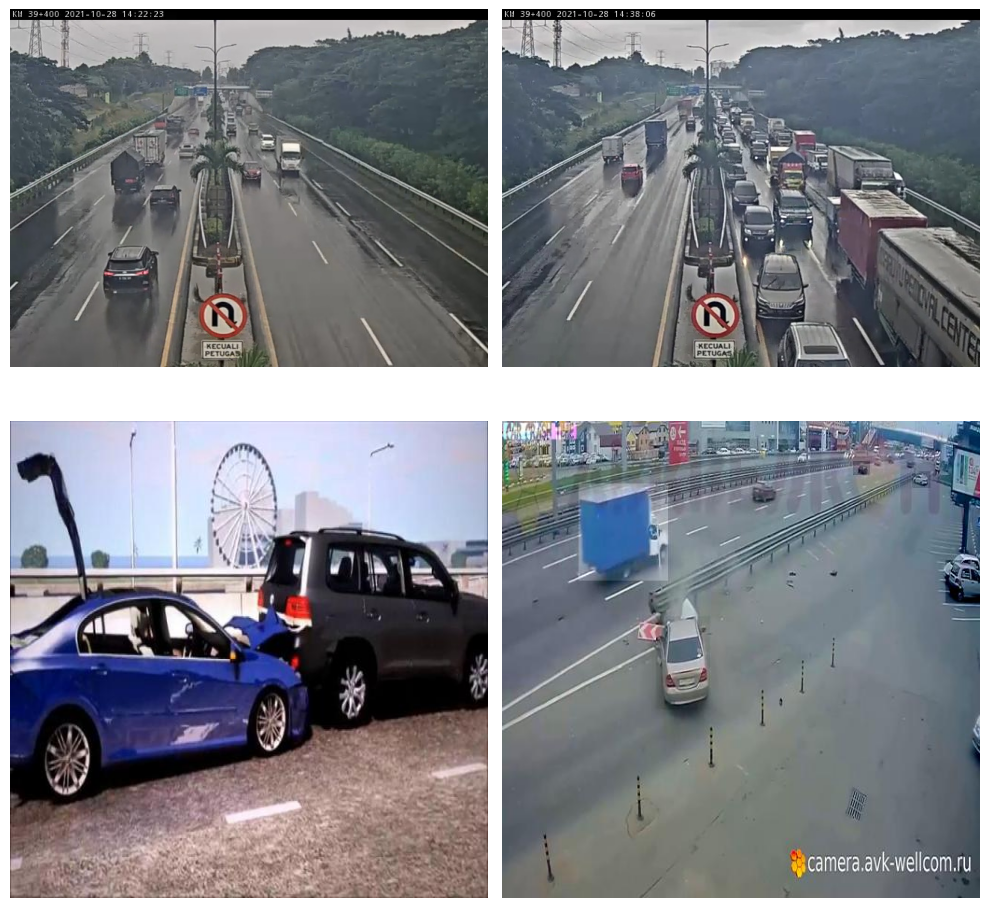

In [ ]:
# Display from training set
train_images = glob.glob('train/images/*.jpg')
if train_images:
    samples = random.sample(train_images, min(4, len(train_images)))
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        if i < len(samples):
            img = mpimg.imread(samples[i])
            ax.imshow(img)
            ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No training images found.')


In [ ]:
img_path = f"train/images/*.jpg"
lbl_path = f"train/labels/*.txt"

images = glob.glob(img_path)
labels = glob.glob(lbl_path)

print(f"train → Images: {len(images)} | Labels: {len(labels)}")

train → Images: 9825 | Labels: 9997


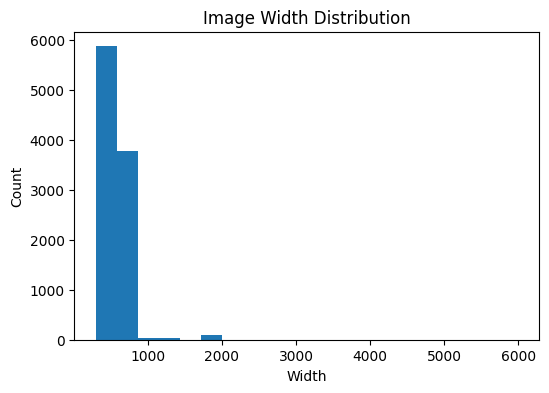

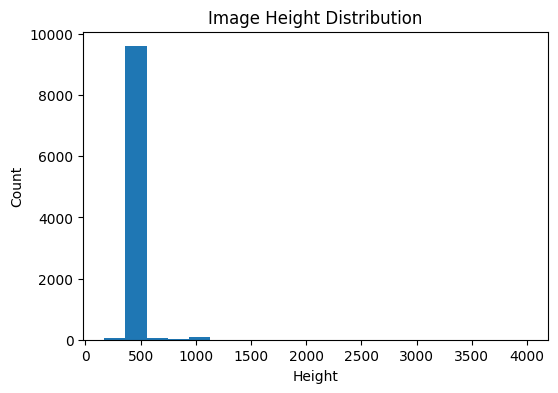

In [ ]:
sizes = []

for img_path in glob.glob("train/images/*.jpg"):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    sizes.append((w, h))

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.figure(figsize=(6,4))
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()

In [17]:
box_widths = []
box_heights = []
classes = []

label_files = glob.glob("train/labels/*.txt")

for file in label_files:
    with open(file, "r") as f:
        for line in f.readlines():
            values = list(map(float, line.split()))
            
            # Take only first 5 values (YOLO bbox)
            if len(values) >= 5:
                c, x, y, w, h = values[:5]
                
                classes.append(int(c))
                box_widths.append(w)
                box_heights.append(h)

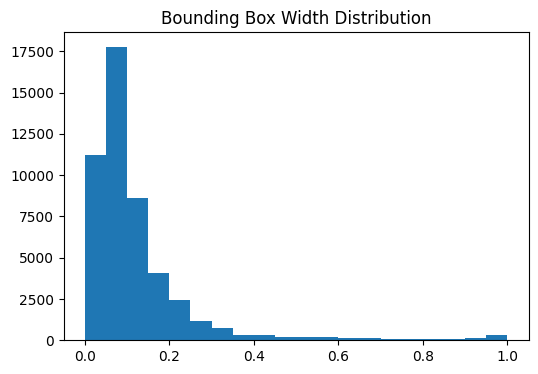

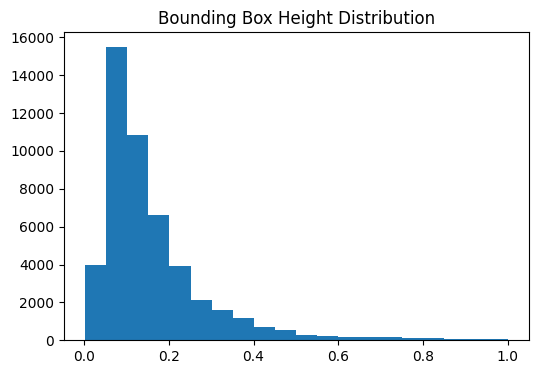

In [18]:
plt.figure(figsize=(6,4))
plt.hist(box_widths, bins=20)
plt.title("Bounding Box Width Distribution")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(box_heights, bins=20)
plt.title("Bounding Box Height Distribution")
plt.show()

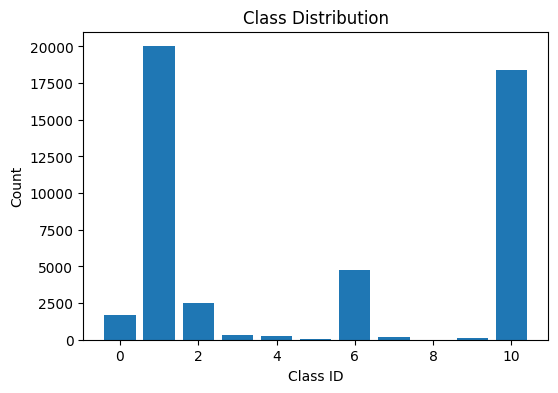

Class counts: Counter({1: 20001, 10: 18417, 6: 4767, 2: 2489, 0: 1712, 3: 351, 4: 278, 7: 219, 9: 147, 5: 31, 8: 7})


In [ ]:
class_counts = Counter(classes)

plt.figure(figsize=(6,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

print("Class counts:", class_counts)

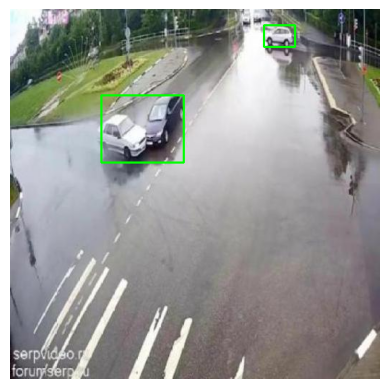

In [ ]:
def show_image_with_boxes(img_path):
    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.readlines():
                c, x, y, bw, bh = map(float, line.split())
                
                # Convert YOLO to pixel coords
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

show_image_with_boxes(random.choice(train_images))

## 4. Image Enhancement (Preprocessing)


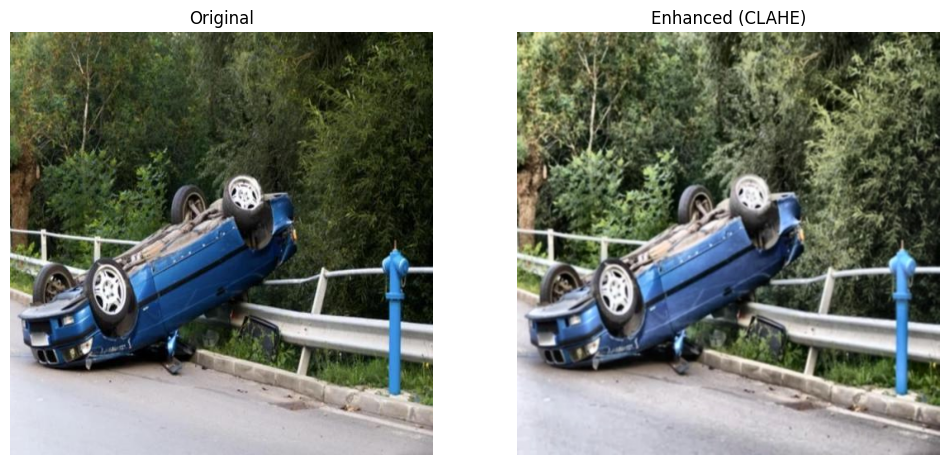

In [ ]:
def apply_clahe(img_path, output_path):
    img = cv2.imread(img_path)
    if img is None:
        print('Image not found')
        return
    # Convert to LAB color space
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    # Apply CLAHE to L-channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    
    # Merge and convert back to BGR
    limg = cv2.merge((cl,a,b))
    enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    
    # Apply slight Gaussian blur to reduce noise
    enhanced_img = cv2.GaussianBlur(enhanced_img, (3, 3), 0)
    
    cv2.imwrite(output_path, enhanced_img)

# Use on one image
if train_images:
    sample_img = train_images[0]
    enhanced_sample = 'enhanced_sample.jpg'
    apply_clahe(sample_img, enhanced_sample)
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    ax1.imshow(cv2.cvtColor(cv2.imread(sample_img), cv2.COLOR_BGR2RGB))
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(cv2.cvtColor(cv2.imread(enhanced_sample), cv2.COLOR_BGR2RGB))
    ax2.set_title('Enhanced (CLAHE)')
    ax2.axis('off')
    plt.show()


In [ ]:
os.makedirs("valid/images", exist_ok=True)
os.makedirs("valid/labels", exist_ok=True)
os.makedirs("test/images", exist_ok=True)
os.makedirs("test/labels", exist_ok=True)

In [ ]:
images = glob.glob("train/images/*.jpg")
random.shuffle(images)

total = len(images)
valid_split = int(0.1 * total)
test_split  = int(0.1 * total)

valid_images = images[:valid_split]
test_images  = images[valid_split:valid_split+test_split]

def move_files(image_list, split):
    for img_path in image_list:
        filename = os.path.basename(img_path)
        label_path = img_path.replace("images","labels").replace(".jpg",".txt")

        shutil.move(img_path, f"{split}/images/{filename}")
        shutil.move(label_path, f"{split}/labels/{filename.replace('.jpg','.txt')}")

move_files(valid_images, "valid")
move_files(test_images, "test")

print("Dataset split complete!")

Dataset split complete!


In [ ]:
for split in ["train","valid","test"]:
    print(split,
          len(glob.glob(f"{split}/images/*.jpg")),
          len(glob.glob(f"{split}/labels/*.txt")))

train 7861 8033
valid 982 982
test 982 982


In [ ]:
os.makedirs("train_clahe/images", exist_ok=True)
os.makedirs("train_clahe/labels", exist_ok=True)

In [ ]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

In [ ]:
image_paths = glob.glob("train/images/*.jpg")

for img_path in image_paths:
    img = cv2.imread(img_path)
    enhanced = apply_clahe(img)

    filename = os.path.basename(img_path)

    # Save enhanced image
    cv2.imwrite(f"train_clahe/images/{filename}", enhanced)

    # Copy label unchanged
    label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")
    shutil.copy(label_path, f"train_clahe/labels/{filename.replace('.jpg','.txt')}")

In [31]:
print("Original images:", len(glob.glob("train/images/*.jpg")))
print("CLAHE images:", len(glob.glob("train_clahe/images/*.jpg")))

Original images: 7861
CLAHE images: 7861
